# Day 2 - H2: Geographic Fault Lines

The second of two Day 2 hypothesis tests. The first (H1: review drivers) lives in `02_h1_review_drivers.ipynb`.

## Hypothesis

**H2.** A small number of seller-state to customer-state routes account for a disproportionate share of late deliveries. If true, the logistics problem is concentrated in specific lanes, not system-wide.

## Why this matters

If H2 holds, Olist can fix late delivery by targeting specific origin-destination lanes (carrier renegotiation, alternative routing) rather than overhauling the whole logistics network. The Pareto framing ("X% of routes drive Y% of complaints") is much more actionable for a business team than "delivery is sometimes bad."

## Methodology

just groupby and means.

1. Build a route-level table: every (seller_state, customer_state) pair with order count, late-delivery rate, mean review, one-star rate.
2. Identify the worst routes by late rate (filtered to routes with at least 100 delivered orders to avoid small-sample noise).
3. Break down late rate by origin state and by destination state separately.
4. Pareto: sort routes by absolute late-delivery count, plot cumulative % captured. Print concrete numbers like "top X% of routes drive Y% of late deliveries".
5. Falsification test: maybe it isn't the route, just the origin. Look at within-origin variance of late rates across destinations. If large variance, route truly matters. If small, only origin matters.


In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load import load_analysis_df

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
sns.set_palette("Set2")

analysis_df = load_analysis_df()

# One row per order. Multi-item orders have one seller_state per item; dedup keeps the first.
order_level = (analysis_df
               .drop_duplicates("order_id")
               .dropna(subset=["seller_state", "customer_state"])
               .copy())

order_level["is_late"] = order_level["promise_gap_days"] < 0  
order_level["is_one_star"] = order_level["review_score"] == 1

print(f"order-level rows for state-pair analysis: {len(order_level):,}")
print(f"  unique seller states:    {order_level['seller_state'].nunique()}")
print(f"  unique customer states:  {order_level['customer_state'].nunique()}")
print(f"  rows with delivery info: {order_level['promise_gap_days'].notna().sum():,}")
print(f"  rows with reviews:       {order_level['review_score'].notna().sum():,}")


order-level rows for state-pair analysis: 98,666
  unique seller states:    23
  unique customer states:  27
  rows with delivery info: 96,476
  rows with reviews:       97,917


## Building the route-level table

For each (seller_state, customer_state) pair, compute:

- `orders`: total order count on that route
- `delivered`: orders that were actually delivered (denominator for late_rate)
- `late_rate`: % of delivered orders that arrived after the estimated date
- `mean_review`: mean review score (excluding orders without reviews)
- `one_star_rate`: % of reviewed orders that got 1 star
- `median_delivery_days`: median actual delivery time in days


In [2]:
route_metrics = (order_level
                 .groupby(["seller_state", "customer_state"])
                 .agg(orders=("order_id", "count"),
                      delivered=("order_delivered_customer_date", "count"),
                      late=("is_late", "sum"),
                      reviewed=("review_score", "count"),
                      one_star=("is_one_star", "sum"),
                      median_delivery_days=("actual_delivery_days", "median"),
                      mean_review=("review_score", "mean"))
                 .reset_index())

# Derived rates with proper denominators.
route_metrics["late_rate"] = route_metrics["late"] / route_metrics["delivered"]
route_metrics["one_star_rate"] = route_metrics["one_star"] / route_metrics["reviewed"]

print(f"Total state-pair routes: {len(route_metrics):,}")
print(f"Routes with >= 100 delivered orders (material): {(route_metrics['delivered'] >= 100).sum():,}")
print(f"Routes with >= 1000 delivered orders:           {(route_metrics['delivered'] >= 1000).sum():,}")


Total state-pair routes: 414
Routes with >= 100 delivered orders (material): 70
Routes with >= 1000 delivered orders:           17


## 1. Worst routes by late-delivery rate


In [3]:
material = route_metrics[route_metrics["delivered"] >= 100].copy()

worst_15 = (material
            .nlargest(15, "late_rate")
            [["seller_state", "customer_state", "orders", "delivered",
              "late_rate", "median_delivery_days", "mean_review"]]
            .copy())

worst_15["late_rate_pct"] = (worst_15["late_rate"] * 100).round(1)
worst_15["mean_review"] = worst_15["mean_review"].round(2)
worst_15["median_delivery_days"] = worst_15["median_delivery_days"].round(0).astype(int)

display_cols = ["seller_state", "customer_state", "orders", "delivered",
                "late_rate_pct", "median_delivery_days", "mean_review"]
worst_15[display_cols].rename(columns={"late_rate_pct": "late_%"})


,seller_state,customer_state,orders,delivered,late_%,median_delivery_days,mean_review
388,SP,AL,265,255,26.3,22,3.64
144,MA,SP,124,123,25.2,13,3.90
396,SP,MA,507,491,21.2,19,3.64
403,SP,PI,343,329,18.2,16,3.88
259,PR,BA,147,143,16.8,18,3.75
411,SP,SE,212,208,16.3,17,3.76
405,SP,RJ,8427,8159,15.5,12,3.82
392,SP,CE,1008,969,15.3,18,3.89
391,SP,BA,2381,2307,15.0,17,3.82
398,SP,MS,483,477,14.7,14,4.05


**Worst routes are dominated by SP origins.** All 15 worst routes by late-delivery rate originate from SP (Sao Paulo), PR (Parana), or MA (Maranhao), and SP is the origin in 11 of 15. The single worst route is SP to AL (Alagoas) at 26.3% late, with median delivery taking 22 days against the platform median of 10. Mean reviews on these routes range from 3.6 to 4.1, all below the platform average around 4.0. Bad routes correlate with bad reviews - which connects H2 directly to H1.


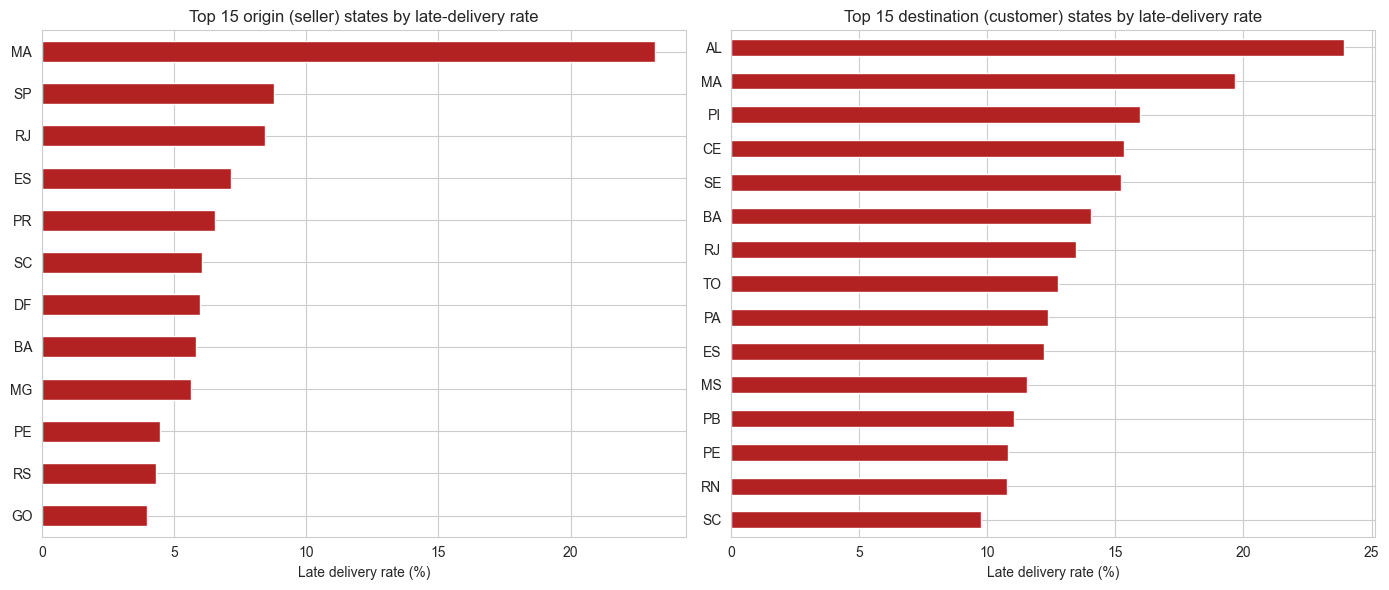

Origin late rate range (top 15): 4.0% to 23.2%
Dest late rate range (top 15):   9.8% to 23.9%

Worst origin state:      MA at 23.2%
Worst destination state: AL at 23.9%


In [4]:
# Late rate by origin (seller) state and by destination (customer) state, separately.
delivered_subset = order_level[order_level["promise_gap_days"].notna()]

by_origin = (delivered_subset
             .groupby("seller_state")
             .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"))
             .query("orders >= 200")
             .sort_values("late_rate", ascending=False))

by_dest = (delivered_subset
           .groupby("customer_state")
           .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"))
           .query("orders >= 200")
           .sort_values("late_rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
(by_origin.head(15)["late_rate"] * 100).plot(kind="barh", ax=axes[0], color="firebrick")
axes[0].set_title("Top 15 origin (seller) states by late-delivery rate")
axes[0].set_xlabel("Late delivery rate (%)")
axes[0].set_ylabel("")
axes[0].invert_yaxis()

(by_dest.head(15)["late_rate"] * 100).plot(kind="barh", ax=axes[1], color="firebrick")
axes[1].set_title("Top 15 destination (customer) states by late-delivery rate")
axes[1].set_xlabel("Late delivery rate (%)")
axes[1].set_ylabel("")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Origin late rate range (top 15): {by_origin.head(15)['late_rate'].min():.1%} to {by_origin.head(15)['late_rate'].max():.1%}")
print(f"Dest late rate range (top 15):   {by_dest.head(15)['late_rate'].min():.1%} to {by_dest.head(15)['late_rate'].max():.1%}")
print()
print(f"Worst origin state:      {by_origin.head(1).index[0]} at {by_origin.head(1)['late_rate'].iloc[0]:.1%}")
print(f"Worst destination state: {by_dest.head(1).index[0]} at {by_dest.head(1)['late_rate'].iloc[0]:.1%}")


**Both origin and destination matter, but separately.** Worst origin state: MA at 23.2% late. Worst destination state: AL at 23.9% late. These are different states. The geographic problem is two-dimensional: sometimes a route is bad because of where it ships from, sometimes because of where it ships to, and the worst routes combine both effects (which is why the worst single route, SP to AL, has a destination state that's also among the worst destinations on its own).


## 2. Pareto concentration

How concentrated are late deliveries across routes? If H2 is right, a small number of routes should account for a large share of late deliveries.


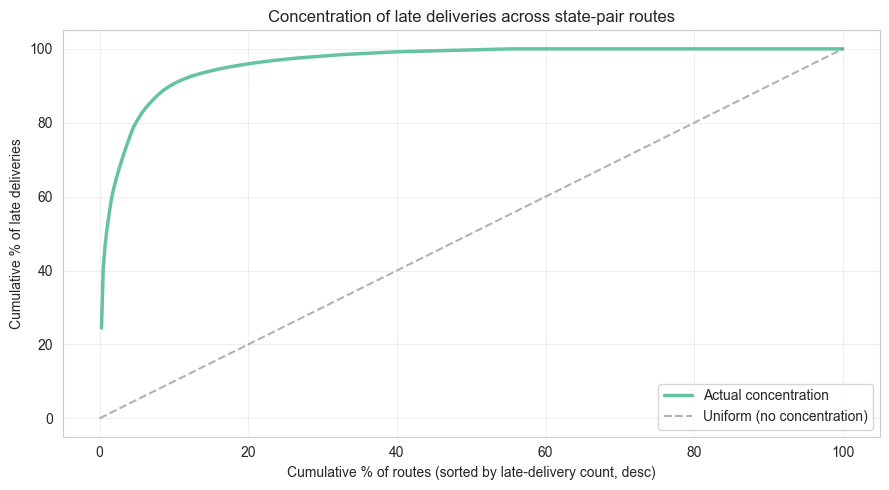

Total routes:               414
Total late deliveries:      7,827

Top   1% of routes (   4 routes) account for 51.0% of late deliveries
Top   5% of routes (  20 routes) account for 79.9% of late deliveries
Top  10% of routes (  41 routes) account for 90.5% of late deliveries
Top  20% of routes (  82 routes) account for 95.9% of late deliveries
Top  50% of routes ( 207 routes) account for 99.7% of late deliveries


In [5]:
sorted_routes = (route_metrics
                 .sort_values("late", ascending=False)
                 .reset_index(drop=True))

total_late = sorted_routes["late"].sum()
sorted_routes["cum_late"] = sorted_routes["late"].cumsum()
sorted_routes["cum_late_pct"] = sorted_routes["cum_late"] / total_late * 100
sorted_routes["cum_routes_pct"] = (sorted_routes.index + 1) / len(sorted_routes) * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sorted_routes["cum_routes_pct"], sorted_routes["cum_late_pct"], linewidth=2.5, label="Actual concentration")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", alpha=0.6, label="Uniform (no concentration)")
ax.set_xlabel("Cumulative % of routes (sorted by late-delivery count, desc)")
ax.set_ylabel("Cumulative % of late deliveries")
ax.set_title("Concentration of late deliveries across state-pair routes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total routes:               {len(sorted_routes):,}")
print(f"Total late deliveries:      {total_late:,}")
print()
for pct in [1, 5, 10, 20, 50]:
    n = max(1, int(len(sorted_routes) * pct / 100))
    captured = sorted_routes.head(n)["late"].sum() / total_late
    print(f"Top {pct:>3}% of routes ({n:>4} routes) account for {captured:.1%} of late deliveries")


**Late deliveries are extremely concentrated across routes.** Of 414 state-pair routes:

- The top **1%** (just 4 routes) account for **51%** of all late deliveries.
- The top **5%** (20 routes) account for **80%**.
- The top **10%** (41 routes) account for **90%**.

This is a textbook Pareto distribution. H2 is strongly confirmed: the logistics problem lives in a small set of specific lanes, not across the whole network. A business team renegotiating carrier SLAs on those top 20 routes would address the vast majority of late-delivery complaints.


## 3. Falsification: route vs origin only

A possible challenge to H2: maybe the destination doesn't matter, only the origin state does. If everything shipping out of a slow origin is slow regardless of destination, "bad routes" is just "bad origins" relabelled.

To test this, take the 5 origin states with the most outbound order volume. For each, compute the late rate by destination state (filtered to destinations with at least 50 orders from that origin). If the spread of late rates within an origin is large, the route genuinely matters. If small, the origin alone explains everything.


In [6]:
# Top 5 origin states by outbound order volume.
top_origins = (order_level.groupby("seller_state").size().nlargest(5).index.tolist())
print(f"Top 5 origin states by volume: {top_origins}")
print()

delivered_top = order_level[
    order_level["seller_state"].isin(top_origins)
    & order_level["promise_gap_days"].notna()
]

# Late rate per (origin, destination) for material destinations from each origin.
fals = (delivered_top
        .groupby(["seller_state", "customer_state"])
        .agg(orders=("order_id", "count"), late_rate=("is_late", "mean"))
        .reset_index()
        .query("orders >= 50"))

# Within-origin spread of destination late rates.
spread = (fals.groupby("seller_state")["late_rate"]
          .agg(min_rate="min", max_rate="max", mean_rate="mean", n_destinations="count")
          .round(4))
spread["spread_pp"] = ((spread["max_rate"] - spread["min_rate"]) * 100).round(1)
spread["min_pct"] = (spread["min_rate"] * 100).round(1)
spread["max_pct"] = (spread["max_rate"] * 100).round(1)
spread["mean_pct"] = (spread["mean_rate"] * 100).round(1)

display_spread = spread[["n_destinations", "min_pct", "max_pct", "mean_pct", "spread_pp"]].rename(
    columns={"min_pct": "min_late_%", "max_pct": "max_late_%", "mean_pct": "mean_late_%",
             "spread_pp": "spread_pp"})
display_spread


Top 5 origin states by volume: ['SP', 'MG', 'PR', 'RJ', 'SC']



,n_destinations,min_late_%,max_late_%,mean_late_%,spread_pp
seller_state,,,,,
MG,16,1.9,16.4,7.4,14.5
PR,15,3.6,16.8,8.1,13.2
RJ,12,2.0,22.2,9.7,20.2
SC,10,1.5,13.0,6.3,11.5
SP,25,3.0,26.3,11.5,23.3


**Falsification result: the route genuinely matters, not just the origin.** Within each of the 5 highest-volume origin states, late rates across destinations vary by 11.5 to 23.3 percentage points:

- From SP, late rates range from 3.0% (best destination) to 26.3% (worst).
- From RJ, 2.0% to 22.2%.
- From MG, 1.9% to 16.4%.
- Even SC, with the smallest spread, varies from 1.5% to 13.0%.

Even shipping out of the same origin, different destinations see dramatically different late rates. This rules out the alternative hypothesis that "bad routes" is just "bad origins" relabelled. The destination genuinely matters. H2 holds.


## 4. Day 2 H2 findings

H2 is strongly confirmed.

### Concentration is extreme
- 414 state-pair routes total. Late deliveries are very unevenly distributed across them.
- **Top 1% of routes (4 routes) account for 51% of all late deliveries.**
- Top 5% (20 routes) account for 80%. Top 10% account for 90%.

### Worst routes
- The single worst route is SP to AL at 26.3% late, with median delivery taking 22 days.
- 11 of the 15 worst routes originate from SP. The geographic problem is dominated by long-haul shipments from Sao Paulo to the north and northeast.

### Origin and destination both matter, but separately
- Worst origin state: MA at 23.2% late.
- Worst destination state: AL at 23.9% late.
- These are different states. Geography is two-dimensional, not a single "bad regions" axis.

### Falsification: route is genuinely route, not origin in disguise
- Within each top-5 origin state, late rates across destinations vary by 11.5 to 23.3 percentage points.
- From SP, the best destination has a 3.0% late rate; the worst has 26.3%.
- The destination genuinely matters.

### Day 3 implications for the Seller Trust Score
- Sellers in chronically-difficult origin regions (e.g. SP shipping to AL) should be benchmarked against route-conditioned expectations, not the platform-wide late rate. A seller in SP whose SP-to-AL late rate is 25% is actually at route average, not bad.
- The Trust Score should include a route-adjustment factor: compare each seller's late rate against the median for the routes they actually serve, then surface the *delta* as the seller's logistics signal.
- Combined with H1 (delivery dominates over category): the Day 3 score should weight delivery-timeliness (route-adjusted) as the primary driver, with a category-specific quality adjustment for `office_furniture` (the H1 falsification exception).
